# Explainability, Refinement and Time-Aware Re-Evaluation

* **Owner:** Dewmi
* **Module:** CCS4310 – Deep Learning
* **Project:** Explainable-Fashion-Design-AI

This notebook implements the parts of the closed-loop architecture

1. **Explainability** – SHAP-based global and per-design (local) explanations for the
   saved demand model, compared against the feature-importance table already produced
   by `03_demand_forecasting.ipynb` (Nilakshi).
2. **Similar-product evidence** – cosine-similarity retrieval against CLIP embeddings
   from the visual-feature module (Dasith), when available.
3. **Refinement** – converts the weakest attributes of a design into concrete
   attribute-swap suggestions and short prompt hints for the generative model (Maleesha).
4. **Closed-loop re-evaluation** – re-scores the refined design with the same model and
   reports the before/after comparison, and reuses the saved
   `predict_with_latest_market_data` pattern for time-aware re-scoring closer to launch.

This notebook only reads disk artifacts (the saved pipeline, its config, and the
preprocessed interim splits). It does not retrain the demand model and does not touch
the untouched test split beyond read-only scoring. All the reusable logic lives in
`src/explainability/` (`shap_explainer.py`, `refinement.py`, `similar_products.py`,
`closed_loop.py`).

In [1]:
from google.colab import drive
import os
import sys
from pathlib import Path

# 1. Mount Google Drive
drive.mount('/content/drive')

project_path = Path('/content/drive/MyDrive/Explainable-Fashion-Design-AI-main')

if project_path.exists():
    os.chdir(project_path)
    print("Successfully changed directory to:", os.getcwd())
else:
    print("Project path not found. Available folders in Drive:")
    !ls /content/drive/MyDrive

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Successfully changed directory to: /content/drive/MyDrive/Explainable-Fashion-Design-AI-main


In [2]:
from pathlib import Path
import json
import sys
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
TOP_N_WEAK_FACTORS = 3
LOCAL_EXAMPLE_ROW = 0  # which test-set row to use for the single-design walkthrough
np.random.seed(RANDOM_STATE)


def find_root():
    for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (p / 'data' / 'interim').is_dir() and (p / 'requirements.txt').exists():
            return p
    raise FileNotFoundError('Repository root not found.')


ROOT = find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

INTERIM = ROOT / 'data' / 'interim'
DEMAND_MODEL_DIR = ROOT / 'models' / 'demand'
METRICS = ROOT / 'outputs' / 'metrics'
FIGURES = ROOT / 'outputs' / 'figures'
for d in [METRICS, FIGURES]:
    d.mkdir(parents=True, exist_ok=True)

from src.explainability.shap_explainer import (
    global_feature_importance,
    explain_row,
    save_global_importance,
)
from src.explainability.refinement import generate_refinement_suggestions, apply_refinement
from src.explainability.similar_products import find_similar_products, load_embeddings
from src.explainability.closed_loop import run_closed_loop, run_closed_loop_batch

print('Using existing shared repository .venv / selected project kernel:', sys.executable)
print('Repository root:', ROOT)

Using existing shared repository .venv / selected project kernel: /usr/bin/python3
Repository root: /content/drive/MyDrive/Explainable-Fashion-Design-AI-main


## 1. Load the saved demand model and its feature configuration

In [3]:
model_path = DEMAND_MODEL_DIR / 'best_demand_model.joblib'
config_path = DEMAND_MODEL_DIR / 'demand_model_config.json'
if not model_path.is_file() or not config_path.is_file():
    raise FileNotFoundError(
        f'Missing {model_path} or {config_path}. Run 03_demand_forecasting.ipynb first '
    )

demand_pipeline = joblib.load(model_path)
demand_config = json.loads(config_path.read_text())

if not hasattr(demand_pipeline, 'named_steps'):
    raise TypeError(
        f"The saved model is '{demand_config.get('selected_model')}', a baseline artifact "
        "without a fitted ('prep','model') pipeline (e.g. Historical Mean or "
        "Previous-Period Naive). SHAP explanations require a fitted tree/linear model; "
        "re-run 03_demand_forecasting.ipynb until a trained model (XGBoost, LightGBM, "
        "Random Forest, or Linear Regression) is selected as the winner."
    )

feature_columns = demand_config['feature_columns']
categorical_features = demand_config['categorical_features']
print('Selected model:', demand_config.get('selected_model'))
print('Run type:', demand_config.get('run_type'))
print('Feature columns:', len(feature_columns))
print('SHAP status:', demand_config.get('shap'))

Selected model: XGBoost
Run type: fast_dev
Feature columns: 17
SHAP status: not implemented; owned by Dewmi


## 2. Load the untouched-until-now feature sample to explain

The same test split used for final evaluation is reused here in read-only, scoring-only mode: SHAP explains predictions, it does not refit anything.

In [4]:
test_path = INTERIM / 'visuelle_demand_test.csv'
if not test_path.is_file():
    raise FileNotFoundError(
        f'Missing {test_path}. Run the Visuelle preprocessing notebook first..! '
    )

test = pd.read_csv(test_path, parse_dates=['time'])
missing = set(feature_columns) - set(test.columns)
if missing:
    raise ValueError(f'Test split is missing required feature columns: {sorted(missing)}')

SHAP_SAMPLE_SIZE = 5000
sample = test.sample(n=min(SHAP_SAMPLE_SIZE, len(test)), random_state=RANDOM_STATE).reset_index(drop=True)
X_explain = sample[feature_columns]
print('Explaining', len(X_explain), 'of', len(test), 'test rows.')

Explaining 5000 of 222355 test rows.


## 3. Global SHAP feature importance

Computed independently of the `feature_importances_`-based table already saved by Nilakshi (`outputs/metrics/demand_feature_importance.csv`), so the two can be compared in the report as two different views of the same model.

In [5]:
shap_importance = save_global_importance(
    demand_pipeline,
    X_explain,
    metrics_path=METRICS / 'dewmi_shap_global_importance.csv',
    figures_path=FIGURES / 'dewmi_shap_global_importance.png',
    top_n=20,
)
display(shap_importance.head(15))

builtin_path = METRICS / 'demand_feature_importance.csv'
if builtin_path.is_file():
    builtin_importance = pd.read_csv(builtin_path, index_col=0)
    comparison = shap_importance.join(builtin_importance, how='inner', rsuffix='_builtin')
    top_overlap = len(set(shap_importance.head(15).index) & set(builtin_importance.head(15).index))
    print(f'{top_overlap}/15 features overlap between the SHAP and feature_importances_ top-15 lists.')
else:
    print('Built-in feature_importances_ table not found; skipping the side-by-side comparison.')

,mean_abs_shap
num__discount_past_1,0.651882
cat__category_printed shirt,0.546226
cat__shop_label_12,0.533945
cat__category_kimono dress,0.390988
cat__fabric_tulle,0.359622
cat__category_long dress,0.265934
cat__shop_label_29,0.236192
num__demand_rolling_mean_3,0.216289
num__calendar_week,0.172326
num__restock_past_1,0.145072


5/15 features overlap between the SHAP and feature_importances_ top-15 lists.


## 4. Local explanation for a single design

Shows why the model gave *this specific* generated design the score it did, using the row-accurate attribute contributions (the SHAP value of the value the design actually has, not just the most negative one-hot column, which can belong to an inactive category).

Base value (average prediction): 1.127
Predicted demand for this design: 5.88


,feature,shap_value
0,num__discount_past_1,0.887550
1,cat__category_printed shirt,0.648022
2,cat__shop_label_12,0.573733
3,cat__fabric_tulle,0.472846
4,cat__category_kimono dress,0.431385
5,cat__category_long dress,0.337586
6,num__demand_rolling_mean_3,-0.233931
7,cat__shop_label_29,0.231234
8,cat__category_short sleeves,0.145373
9,cat__color_white,0.139438


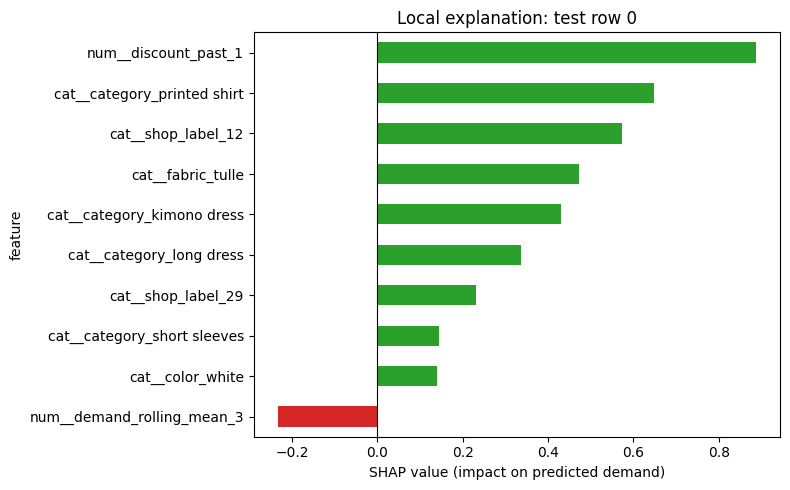


This design's actual attribute values and their contribution:


,attribute,current_value,shap_value
0,color,brown,-0.013886
1,season,AW19,0.000000
2,fabric,georgette,0.002924
3,shop_label,9,0.002999
4,category,long sleeve,0.006917


In [6]:
explanation = explain_row(demand_pipeline, X_explain, row_index=LOCAL_EXAMPLE_ROW)
print('Base value (average prediction):', round(explanation.base_value, 3))
print('Predicted demand for this design:', round(explanation.predicted_value, 3))

top_factors = explanation.top_contributions(n=10, direction='both')
display(top_factors)

fig, ax = plt.subplots(figsize=(8, 5))
plot_df = top_factors.set_index('feature')['shap_value'].sort_values()
colors = ['#d62728' if v < 0 else '#2ca02c' for v in plot_df.values]
plot_df.plot.barh(ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('SHAP value (impact on predicted demand)')
ax.set_title(f'Local explanation: test row {LOCAL_EXAMPLE_ROW}')
fig.tight_layout()
fig.savefig(FIGURES / 'dewmi_shap_local_example.png', dpi=150)
plt.show()

attribute_view = explanation.attribute_contributions(categorical_features)
print('\nThis design\'s actual attribute values and their contribution:')
display(attribute_view)

## 5. Similar-product evidence (optional, requires saved CLIP embeddings)

Reuses the cosine-similarity pattern from Dasith's visual-feature notebook. This section is skipped gracefully if embeddings have not been extracted and saved yet — it is evidence to *support* the SHAP explanation, not a hard requirement for it.

In [7]:
embeddings_path = ROOT / 'data' / 'processed' / 'visual_features' / 'deepfashion_clip_embeddings.npy'
embeddings_metadata_path = ROOT / 'data' / 'processed' / 'visual_features' / 'deepfashion_clip_metadata.csv'

if embeddings_path.is_file() and embeddings_metadata_path.is_file():
    reference_embeddings, reference_metadata = load_embeddings(embeddings_path, embeddings_metadata_path)
    query_index = 0  # index of the generated design's embedding within reference_embeddings
    outcome_col = 'demand' if 'demand' in reference_metadata.columns else None
    similar = find_similar_products(
        reference_embeddings[query_index],
        reference_embeddings,
        reference_metadata,
        top_k=5,
        outcome_column=outcome_col,
    )
    display(similar)
else:
    print(
        'Saved CLIP embeddings not found at',
        embeddings_path,
        '- these are only written when 02_visual_features.ipynb is run with '
        'RUN_CLIP_EXTRACTION=True. Please run that notebook first to save '
        'deepfashion_clip_embeddings.npy and deepfashion_clip_metadata.csv.'
    )

Saved CLIP embeddings not found at /content/drive/MyDrive/Explainable-Fashion-Design-AI-main/data/processed/visual_features/deepfashion_clip_embeddings.npy - these are only written when 02_visual_features.ipynb is run with RUN_CLIP_EXTRACTION=True. Please run that notebook first to save deepfashion_clip_embeddings.npy and deepfashion_clip_metadata.csv.


## 6. Refinement suggestions for the weakest attributes

In [8]:
suggestions = generate_refinement_suggestions(
    explanation,
    categorical_features=categorical_features,
    importance_table=shap_importance,
    top_n_weak_factors=TOP_N_WEAK_FACTORS,
)

if not suggestions:
    print('No categorical attribute of this design has a negative SHAP contribution; '
          'nothing to refine for this example row.')
else:
    for s in suggestions:
        print(f'- {s.reason}')
    refined_row = apply_refinement(X_explain.iloc[LOCAL_EXAMPLE_ROW], suggestions)
    print('\nOriginal attributes:', X_explain.iloc[LOCAL_EXAMPLE_ROW][categorical_features].to_dict())
    print('Refined attributes: ', refined_row[categorical_features].to_dict())

- 'color=brown' contributes -0.014 to the predicted score; 'color=white' has the strongest average positive SHAP contribution for this attribute.

Original attributes: {'season': 'AW19', 'season_from_time': 'autumn', 'category': 'long sleeve', 'color': 'brown', 'fabric': 'georgette', 'shop_label': 9}
Refined attributes:  {'season': 'AW19', 'season_from_time': 'autumn', 'category': 'long sleeve', 'color': 'white', 'fabric': 'georgette', 'shop_label': 9}


## 7. Closed-loop re-evaluation: original vs refined design

Re-scores the refined design with the *same* saved model (no refitting) and reports the improvement. This is the automated score-guided refinement route shown in Figure 2 of the project document; the refined attributes/prompt hints are what would be sent back to Maleesha's generator to actually produce the improved image.

Original predicted demand: 1.668
Refined predicted demand:  1.685
Delta: 0.017 | Improved: True
Prompt hints for the generator: ['use white instead of brown for the color']


,row_index,original_score,refined_score,score_delta,improved,n_suggestions,prompt_hints
0,0,1.667643,1.684867,0.017224,True,1,use white instead of brown for the color
1,1,2.397891,2.664078,0.266187,True,2,use white instead of black for the color; use ...
2,2,1.018449,1.533110,0.514661,True,3,use tulle instead of hron for the fabric; use ...
3,3,0.785199,0.785199,0.000000,False,0,
4,4,1.448142,1.776454,0.328312,True,1,use printed shirt instead of culottes for the ...
5,5,1.341966,1.413083,0.071117,True,2,use white instead of black for the color; use ...
6,6,1.073580,1.073580,0.000000,False,0,
7,7,1.070741,1.114854,0.044114,True,1,use white instead of black for the color
8,8,0.641391,0.641391,0.000000,False,0,
9,9,1.676837,1.749336,0.072499,True,1,use white instead of grey for the color



65.5% of the 200 sampled designs improved after refinement.
Mean score delta: 0.131


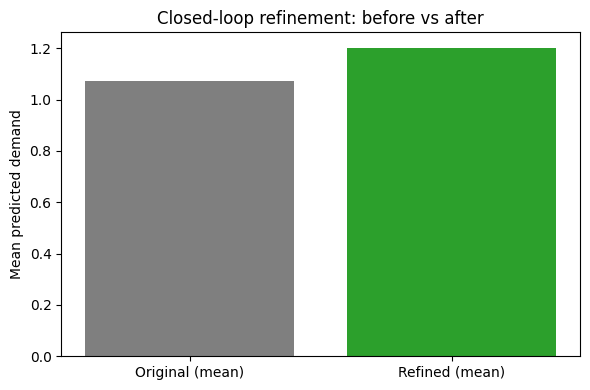

In [9]:
single_result = run_closed_loop(
    demand_pipeline,
    X_explain,
    categorical_features=categorical_features,
    row_index=LOCAL_EXAMPLE_ROW,
    importance_table=shap_importance,
    top_n_weak_factors=TOP_N_WEAK_FACTORS,
)
print('Original predicted demand:', round(single_result.original_score, 3))
print('Refined predicted demand: ', round(single_result.refined_score, 3))
print('Delta:', round(single_result.score_delta, 3), '| Improved:', single_result.improved)
print('Prompt hints for the generator:', single_result.prompt_hints)

BATCH_SIZE = min(200, len(X_explain))
batch_indices = list(range(BATCH_SIZE))
comparison = run_closed_loop_batch(
    demand_pipeline,
    X_explain,
    categorical_features=categorical_features,
    row_indices=batch_indices,
    top_n_weak_factors=TOP_N_WEAK_FACTORS,
)
comparison.to_csv(METRICS / 'dewmi_closed_loop_comparison.csv', index=False)
display(comparison.head(10))

print(f'\n{comparison.improved.mean():.1%} of the {len(comparison)} sampled designs improved after refinement.')
print('Mean score delta:', round(comparison.score_delta.mean(), 3))

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Original (mean)', 'Refined (mean)'],
       [comparison.original_score.mean(), comparison.refined_score.mean()],
       color=['#7f7f7f', '#2ca02c'])
ax.set_ylabel('Mean predicted demand')
ax.set_title('Closed-loop refinement: before vs after')
fig.tight_layout()
fig.savefig(FIGURES / 'dewmi_closed_loop_score_comparison.png', dpi=150)
plt.show()

## 8. Time-aware re-evaluation

Reuses the exact `predict_with_latest_market_data`-style pattern already established by Nilakshi's notebook: the saved pipeline and feature schema are used to re-score a design once newer, genuinely observed market rows become available closer to its intended launch period. No future information is fabricated and nothing is refit here.

In [10]:
def re_evaluate_closer_to_launch(latest_market_rows, pipeline=demand_pipeline, required_columns=feature_columns):
    """Re-score prepared rows with newer market information using the saved pipeline.

    ``latest_market_rows`` must already be prepared with the same schema as
    ``feature_columns`` (e.g. updated demand_lag_*, restock_past_1, price_past_1,
    discount_past_1, and a season/season_from_time consistent with the new launch date).
    This function does not compute those features itself and does not refit the model;
    it only applies the frozen pipeline to genuinely newer, already-prepared data.
    """
    frame = pd.DataFrame(latest_market_rows).copy()
    missing_cols = set(required_columns) - set(frame.columns)
    if missing_cols:
        raise ValueError(f'Missing required prepared features: {sorted(missing_cols)}')
    return pipeline.predict(frame[required_columns])


# Demonstration only: re-uses one already-prepared test row as a stand-in for a design
demo_rows = X_explain.iloc[[LOCAL_EXAMPLE_ROW]]
print('Re-evaluated score with the frozen pipeline:', re_evaluate_closer_to_launch(demo_rows)[0])
print('This function is ready for real prepared rows once newer market data is available; '
      'it deliberately raises if required columns are missing rather than silently guessing.')

Re-evaluated score with the frozen pipeline: 1.6676428
This function is ready for real prepared rows once newer market data is available; it deliberately raises if required columns are missing rather than silently guessing.


## Conclusion

This notebook share of the closed-loop architecture end to end:

- **Explainability** – global SHAP importance (compared against the built-in
  `feature_importances_` table) and a row-accurate local explanation per design.
- **Similar-product evidence** – cosine-similarity retrieval against CLIP embeddings,
  wired up and ready as soon as Dasith's embeddings are saved to disk.
- **Refinement** – SHAP-driven, rule-based attribute-swap suggestions and prompt hints
  for the generative model.
- **Closed-loop re-evaluation** – before/after re-scoring with the same frozen model,
  plus a batch view (`dewmi_closed_loop_comparison.csv`) suitable for the project's
  success-criteria table (Section 10.2: "Refined designs achieve a meaningful improvement
  in the combined market-alignment score").
- **Time-aware re-evaluation** – a frozen-pipeline re-scoring function for when newer
  market information becomes available closer to a design's launch window.

All reusable logic lives in `src/explainability/` so the same functions can back the
planned FastAPI explainability service without duplicating code. Results here are
development/pipeline-validation results only, computed on a capped sample of the test
split; a final run should raise or remove `SHAP_SAMPLE_SIZE` and use the full test set.